# NYC Mobility EDA 

This notebook is intended to run **after** `01_initial_exploration.ipynb`.
If `df` already exists in memory, it reuses it. Otherwise, it falls back to loading from `data/raw`.

**Deliverables covered**
- Data sanity checks: time gaps, invalid trips, weird zones
- Demand patterns: hour/day/season + borough/zone heatmaps
- Outlier analysis + cleaning rules
- Baseline feature preview
- Export plots to `reports/figures/`


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

In [3]:
# Notebook lives in notebooks/exploratory, so use relative paths like 01_initial_exploration
DATA_DIR = Path('../../data/processed').resolve()
FIG_DIR = Path('../../reports/figures').resolve()
EXT_DIR = Path('../../data/external').resolve()

FIG_DIR.mkdir(parents=True, exist_ok=True)
EXT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data dir: {DATA_DIR}")
print(f"Figure dir: {FIG_DIR}")


Data dir: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\data\processed
Figure dir: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\reports\figures


In [2]:
def savefig(name: str, dpi: int = 140):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


def load_zone_lookup() -> pd.DataFrame:
    local_path = EXT_DIR / "taxi_zone_lookup.csv"
    if local_path.exists():
        z = pd.read_csv(local_path)
        return z

    remote_url = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
    try:
        z = pd.read_csv(remote_url)
        z.to_csv(local_path, index=False)
        print(f"Downloaded zone lookup to {local_path}")
        return z
    except Exception as exc:
        print(f"Zone lookup unavailable: {exc}")
        return pd.DataFrame(columns=["LocationID", "Borough", "Zone", "service_zone"])


def detect_vehicle_type(filename: str) -> str:
    n = filename.lower()
    if "yellow" in n:
        return "yellow"
    if "green" in n:
        return "green"
    if "fhvhv" in n:
        return "fhvhv"
    if "fhv" in n:
        return "fhv"
    return "unknown"


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    mapping = {
        "tpep_pickup_datetime": "pickup_datetime",
        "tpep_dropoff_datetime": "dropoff_datetime",
        "lpep_pickup_datetime": "pickup_datetime",
        "lpep_dropoff_datetime": "dropoff_datetime",
        "dropOff_datetime": "dropoff_datetime",
        "PULocationID": "pickup_location_id",
        "DOLocationID": "dropoff_location_id",
        "PUlocationID": "pickup_location_id",
        "DOlocationID": "dropoff_location_id",
        "trip_miles": "trip_distance",
        "base_passenger_fare": "fare_amount",
    }
    out = df.rename(columns=mapping).copy()

    for col in ["pickup_datetime", "dropoff_datetime"]:
        if col in out.columns:
            out[col] = pd.to_datetime(out[col], errors="coerce")

    if {"pickup_datetime", "dropoff_datetime"}.issubset(out.columns):
        out["trip_duration_min"] = (out["dropoff_datetime"] - out["pickup_datetime"]).dt.total_seconds() / 60.0

    return out


In [3]:
raw_files = sorted(RAW_DIR.glob("*.parquet"))
print(f"Raw files available in {RAW_DIR}: {len(raw_files)}")
if raw_files:
    print("Sample files:")
    for p in raw_files[:5]:
        print(" -", p.name)


Raw files available in C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\data\processed: 1
Sample files:
 - yellow_tripdata_2024-01.parquet


## 1) Use existing data frame (preferred) or fallback load

Preferred workflow:
1. Run `01_initial_exploration.ipynb` first.
2. Keep a cleaned/working `df` in memory.
3. Run this notebook for deeper EDA outputs.


In [4]:
# Reuse df from prior notebook if available; fallback to local raw files
if 'df' in globals() and isinstance(df, pd.DataFrame) and len(df) > 0:
    print(f"Using existing df from current kernel: {len(df):,} rows")
    raw_df = standardize_columns(df.copy())
else:
    if not raw_files:
        raise FileNotFoundError(f"No parquet files found in {RAW_DIR} and no existing df in memory.")

    # Match 01_initial_exploration behavior first: load one yellow sample
    yellow_files = [f for f in raw_files if 'yellow' in f.name.lower()]
    sample_file = yellow_files[0] if yellow_files else raw_files[0]
    print(f"Loading fallback sample: {sample_file.name}")

    tmp = pd.read_parquet(sample_file)
    tmp["source_file"] = sample_file.name
    tmp["vehicle_type"] = detect_vehicle_type(sample_file.name)
    raw_df = standardize_columns(tmp)

MAX_ROWS = 500_000
if len(raw_df) > MAX_ROWS:
    df = raw_df.sample(MAX_ROWS, random_state=42).copy()
else:
    df = raw_df.copy()

print(f"EDA rows used: {len(df):,}")
print(f"Columns in df: {list(df.columns)}")


Loading fallback sample: yellow_tripdata_2024-01.parquet


EDA rows used: 500,000
Columns in df: ['VendorID', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'pickup_location_id', 'dropoff_location_id', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'trip_duration_seconds', 'vehicle_type', 'pickup_year', 'pickup_month', 'pickup_day', 'pickup_hour', 'pickup_dayofweek', 'pickup_weekday', 'time_of_day', 'source_file', 'trip_duration_min']


## 2) Data sanity checks

In [5]:
zone_lookup = load_zone_lookup()
valid_zone_ids = set(zone_lookup["LocationID"].dropna().astype(int).tolist()) if not zone_lookup.empty else set(range(1, 266))

# Create helper fields
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_dow"] = df["pickup_datetime"].dt.day_name()
df["pickup_month"] = df["pickup_datetime"].dt.month
df["season"] = pd.Categorical(
    np.select(
        [df["pickup_month"].isin([12, 1, 2]), df["pickup_month"].isin([3, 4, 5]), df["pickup_month"].isin([6, 7, 8])],
        ["winter", "spring", "summer"],
        default="fall",
    ),
    categories=["winter", "spring", "summer", "fall"],
    ordered=True,
)

# Invalid trip rules
invalid = pd.DataFrame(index=df.index)
invalid["null_pickup_or_dropoff"] = df["pickup_datetime"].isna() | df["dropoff_datetime"].isna()
invalid["non_positive_duration"] = df["trip_duration_min"].fillna(-1) <= 0
invalid["duration_gt_24h"] = df["trip_duration_min"].fillna(0) > 24 * 60
invalid["negative_distance"] = df["trip_distance"].fillna(0) < 0
invalid["distance_gt_100mi"] = df["trip_distance"].fillna(0) > 100
invalid["negative_fare"] = df["fare_amount"].fillna(0) < 0
invalid["fare_gt_1000"] = df["fare_amount"].fillna(0) > 1000
invalid["weird_pickup_zone"] = ~df["pickup_location_id"].fillna(-1).astype(int).isin(valid_zone_ids)
invalid["weird_dropoff_zone"] = ~df["dropoff_location_id"].fillna(-1).astype(int).isin(valid_zone_ids)

invalid_summary = invalid.mean().sort_values(ascending=False).to_frame("fraction")
invalid_summary["percent"] = (invalid_summary["fraction"] * 100).round(2)
invalid_summary


,fraction,percent
null_pickup_or_dropoff,0.0,0.0
non_positive_duration,0.0,0.0
duration_gt_24h,0.0,0.0
negative_distance,0.0,0.0
distance_gt_100mi,0.0,0.0
negative_fare,0.0,0.0
fare_gt_1000,0.0,0.0
weird_pickup_zone,0.0,0.0
weird_dropoff_zone,0.0,0.0


Saved: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\reports\figures\eda_invalid_rates.png


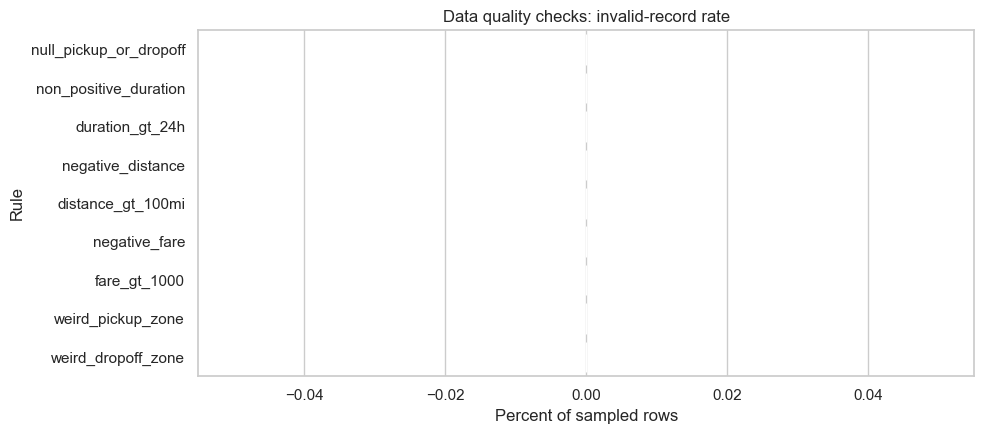

In [6]:
# Plot invalid rates
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_invalid = invalid_summary.sort_values("percent", ascending=False).reset_index()
sns.barplot(data=plot_invalid, x="percent", y="index", ax=ax, palette="Reds_r")
ax.set_title("Data quality checks: invalid-record rate")
ax.set_xlabel("Percent of sampled rows")
ax.set_ylabel("Rule")
savefig("eda_invalid_rates.png")
plt.show()


Missing-hour gaps: 0 / 746 hours


Saved: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\reports\figures\eda_time_gaps_timeline.png


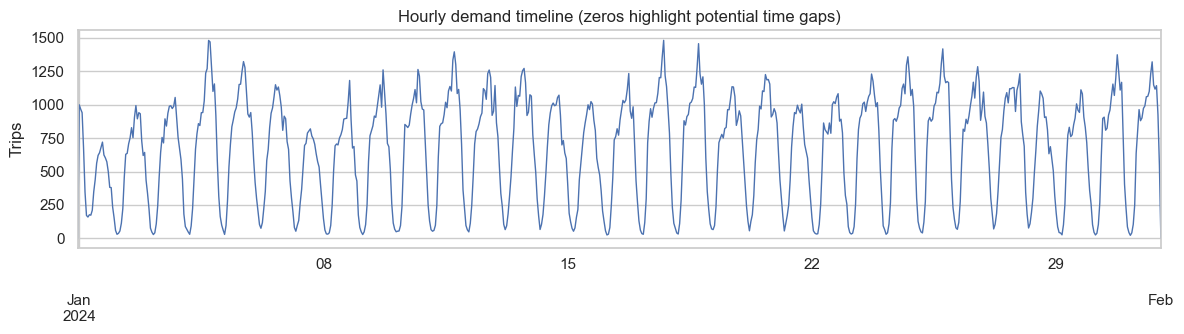

In [7]:
# Time gap check: missing hours between min/max pickup datetime
valid_time = df.dropna(subset=["pickup_datetime"]).copy()
if len(valid_time):
    hourly = (
        valid_time
        .set_index("pickup_datetime")
        .resample("H")
        .size()
        .rename("trip_count")
        .to_frame()
    )
    full_idx = pd.date_range(hourly.index.min(), hourly.index.max(), freq="H")
    hourly = hourly.reindex(full_idx, fill_value=0)
    gap_count = int((hourly["trip_count"] == 0).sum())
    print(f"Missing-hour gaps: {gap_count:,} / {len(hourly):,} hours")

    fig, ax = plt.subplots(figsize=(12, 3.5))
    hourly["trip_count"].plot(ax=ax, lw=1)
    ax.set_title("Hourly demand timeline (zeros highlight potential time gaps)")
    ax.set_ylabel("Trips")
    savefig("eda_time_gaps_timeline.png")
    plt.show()
else:
    print("No valid pickup_datetime available for time gap analysis.")


## 3) Demand patterns

Saved: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\reports\figures\eda_demand_hour_day_season.png


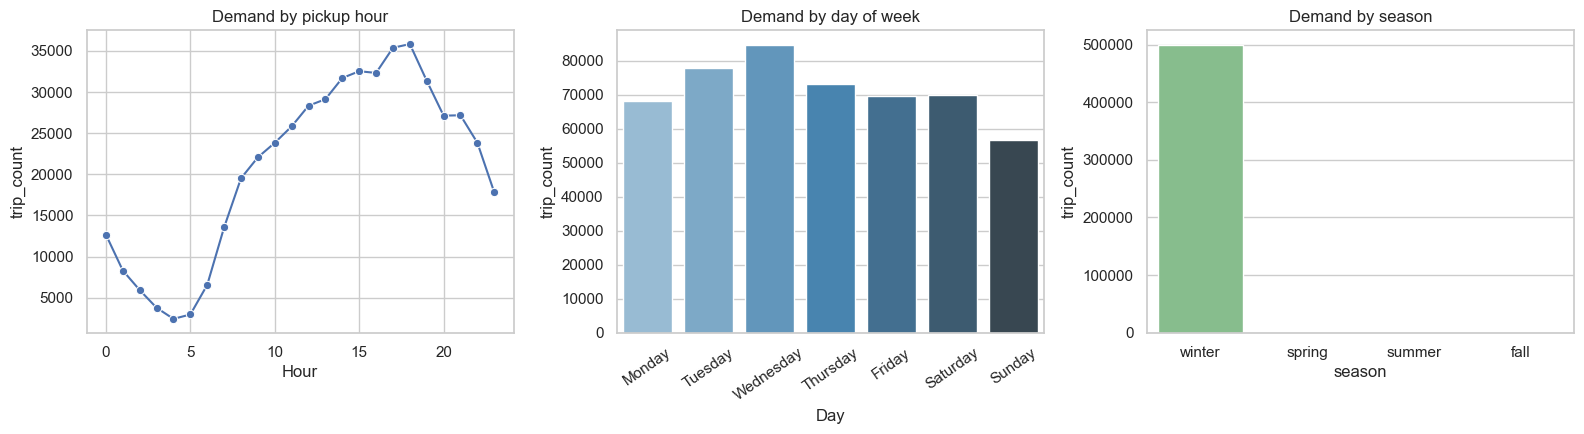

In [8]:
order_dow = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Hourly
hour_counts = df.groupby("pickup_hour", dropna=True).size().reset_index(name="trip_count")
sns.lineplot(data=hour_counts, x="pickup_hour", y="trip_count", marker="o", ax=axes[0])
axes[0].set_title("Demand by pickup hour")
axes[0].set_xlabel("Hour")

# Day of week
dow_counts = (
    df.groupby("pickup_dow", dropna=True).size().reindex(order_dow).reset_index(name="trip_count")
)
sns.barplot(data=dow_counts, x="pickup_dow", y="trip_count", ax=axes[1], palette="Blues_d")
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_title("Demand by day of week")
axes[1].set_xlabel("Day")

# Season
season_counts = df.groupby("season", dropna=True).size().reset_index(name="trip_count")
sns.barplot(data=season_counts, x="season", y="trip_count", ax=axes[2], palette="Greens_d")
axes[2].set_title("Demand by season")

savefig("eda_demand_hour_day_season.png")
plt.show()


Saved: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\reports\figures\eda_borough_hour_heatmap.png


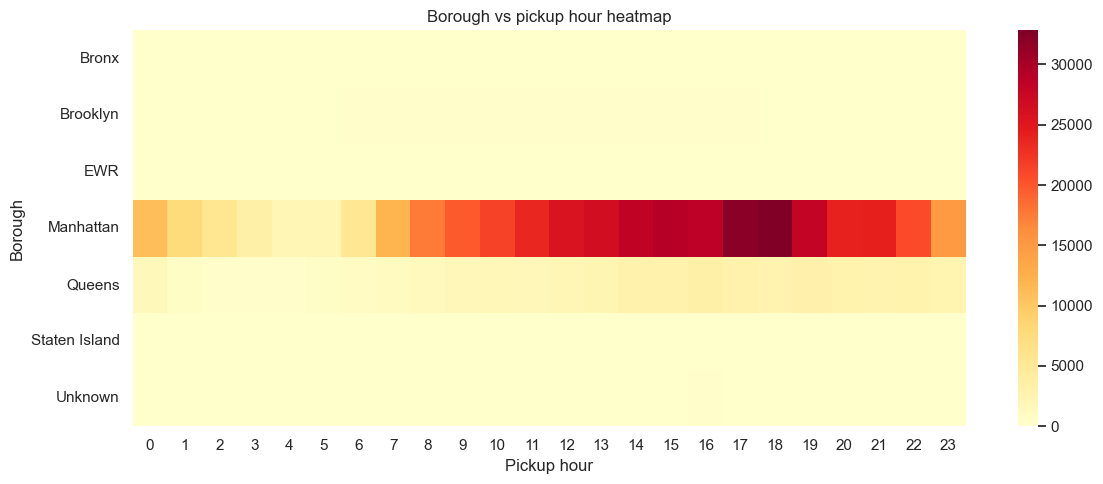

In [9]:
# Borough x hour heatmap (if zone lookup available)
plot_df = df.copy()
if not zone_lookup.empty:
    borough_map = zone_lookup[["LocationID", "Borough"]].drop_duplicates()
    plot_df = plot_df.merge(
        borough_map.rename(columns={"LocationID": "pickup_location_id"}),
        on="pickup_location_id",
        how="left",
    )
else:
    plot_df["Borough"] = "Unknown"

heat_b = (
    plot_df.dropna(subset=["pickup_hour"])
    .groupby(["Borough", "pickup_hour"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat_b, cmap="YlOrRd", ax=ax)
ax.set_title("Borough vs pickup hour heatmap")
ax.set_xlabel("Pickup hour")
ax.set_ylabel("Borough")
savefig("eda_borough_hour_heatmap.png")
plt.show()


Saved: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\reports\figures\eda_zone_hour_heatmap.png


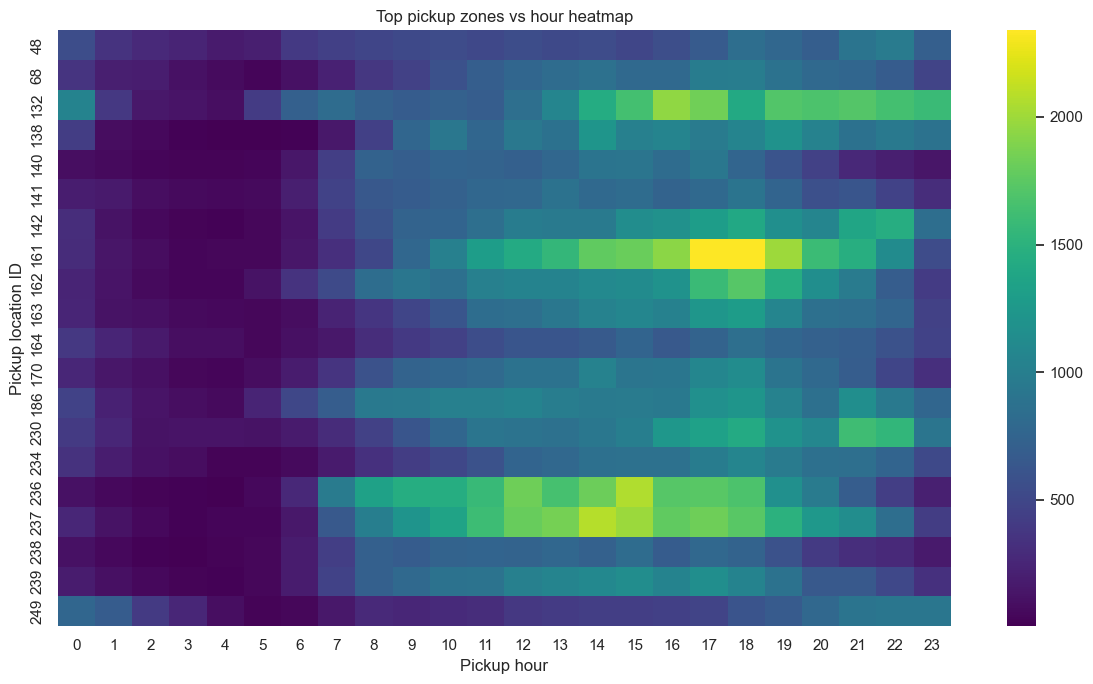

In [10]:
# Zone heatmap: top 20 pickup zones by volume, across hour
top_zones = (
    df.groupby("pickup_location_id")
    .size()
    .sort_values(ascending=False)
    .head(20)
    .index
)
zone_hour = (
    df[df["pickup_location_id"].isin(top_zones)]
    .groupby(["pickup_location_id", "pickup_hour"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(zone_hour, cmap="viridis", ax=ax)
ax.set_title("Top pickup zones vs hour heatmap")
ax.set_xlabel("Pickup hour")
ax.set_ylabel("Pickup location ID")
savefig("eda_zone_hour_heatmap.png")
plt.show()


## 4) Outlier analysis + cleaning rules

Saved: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\reports\figures\eda_outlier_boxplots.png


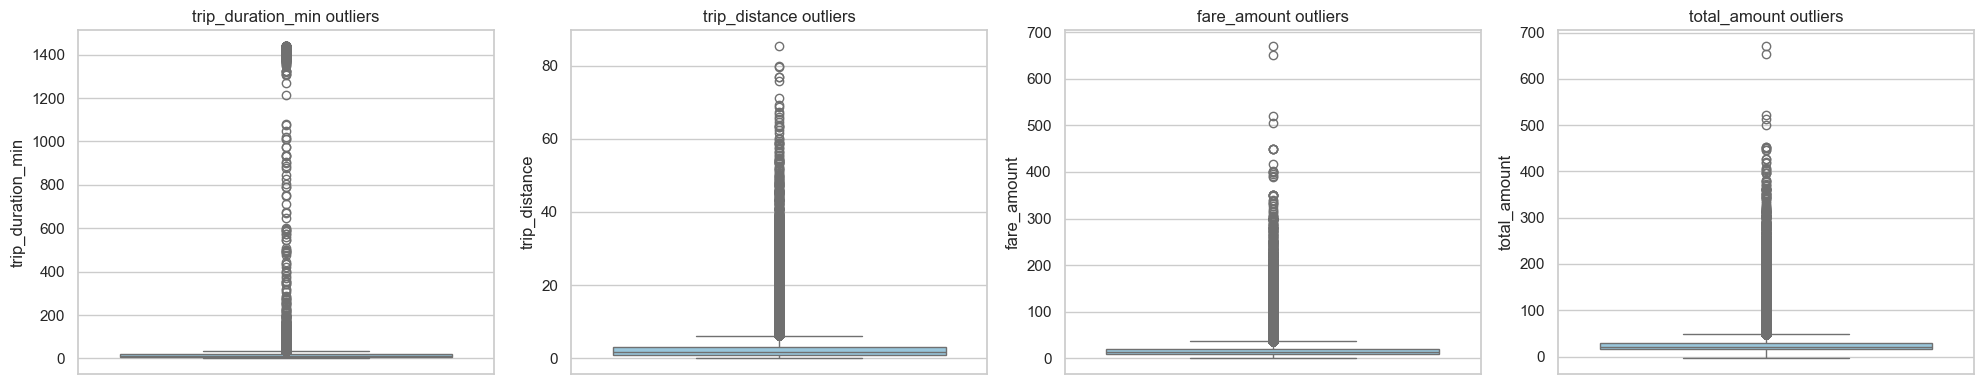

,feature,iqr_low,iqr_high,outlier_pct
0,trip_duration_min,-10.15,35.85,5.97
1,trip_distance,-2.15,6.25,12.96
2,fare_amount,-8.20,36.60,10.88


In [11]:
numeric_cols = ["trip_duration_min", "trip_distance", "fare_amount", "total_amount"]
avail_num = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(1, len(avail_num), figsize=(5 * len(avail_num), 4))
if len(avail_num) == 1:
    axes = [axes]

for ax, col in zip(axes, avail_num):
    sns.boxplot(y=df[col], ax=ax, color="#8ecae6")
    ax.set_title(f"{col} outliers")

savefig("eda_outlier_boxplots.png")
plt.show()


def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

rule_table = []
for c in ["trip_duration_min", "trip_distance", "fare_amount"]:
    if c in df.columns:
        lo, hi = iqr_bounds(df[c].dropna())
        frac = ((df[c] < lo) | (df[c] > hi)).mean() * 100
        rule_table.append({"feature": c, "iqr_low": round(lo, 2), "iqr_high": round(hi, 2), "outlier_pct": round(frac, 2)})

rules_df = pd.DataFrame(rule_table)
rules_df


In [12]:
# Practical cleaning rules (explicit)
clean_rules = {
    "trip_duration_min": (0, 24 * 60),
    "trip_distance": (0, 100),
    "fare_amount": (0, 1000),
    "passenger_count": (0, 8),
}

clean_mask = pd.Series(True, index=df.index)
for col, (lo, hi) in clean_rules.items():
    if col in df.columns:
        clean_mask &= df[col].isna() | ((df[col] >= lo) & (df[col] <= hi))

clean_df = df[clean_mask].copy()
removed_pct = (1 - len(clean_df) / len(df)) * 100
print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning:  {len(clean_df):,}")
print(f"Rows removed:         {removed_pct:.2f}%")


Rows before cleaning: 500,000
Rows after cleaning:  500,000
Rows removed:         0.00%


## 5) Baseline features preview (predictiveness signals)

In [13]:
model_df = clean_df.copy()

# Feature engineering
model_df["pickup_hour"] = model_df["pickup_datetime"].dt.hour
model_df["pickup_dayofweek"] = model_df["pickup_datetime"].dt.dayofweek
model_df["pickup_month"] = model_df["pickup_datetime"].dt.month

feature_cols_num = [c for c in ["pickup_hour", "pickup_dayofweek", "pickup_month", "trip_distance", "passenger_count"] if c in model_df.columns]
feature_cols_cat = [c for c in ["vehicle_type", "payment_type", "pickup_location_id", "dropoff_location_id"] if c in model_df.columns]

target = "fare_amount" if "fare_amount" in model_df.columns else None
if target is None:
    raise ValueError("fare_amount not available for baseline feature preview.")

model_df = model_df.dropna(subset=[target])
model_df = model_df[feature_cols_num + feature_cols_cat + [target]].dropna()

if len(model_df) > 150_000:
    model_df = model_df.sample(150_000, random_state=42)

X = model_df[feature_cols_num + feature_cols_cat]
y = model_df[target]

pre = ColumnTransformer(
    transformers=[
        ("num", "passthrough", feature_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ]
)

rf = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
pipe = Pipeline([("pre", pre), ("model", rf)])
pipe.fit(X, y)

# Recover feature names after one-hot encoding
feature_names = pipe.named_steps["pre"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)
fi.head(15)


,feature,importance
3,num__trip_distance,0.870142
0,num__pickup_hour,0.022053
1,num__pickup_dayofweek,0.011344
491,cat__dropoff_location_id_265,0.011224
6,cat__payment_type_1,0.006684
239,cat__pickup_location_id_265,0.005573
4,num__passenger_count,0.005302
240,cat__dropoff_location_id_1,0.003815
120,cat__pickup_location_id_132,0.003467
362,cat__dropoff_location_id_132,0.003198


Saved: C:\Users\user\Documents\Winter26\EnterPri\Project\nyc-mobility-analysis\reports\figures\eda_baseline_feature_importance.png


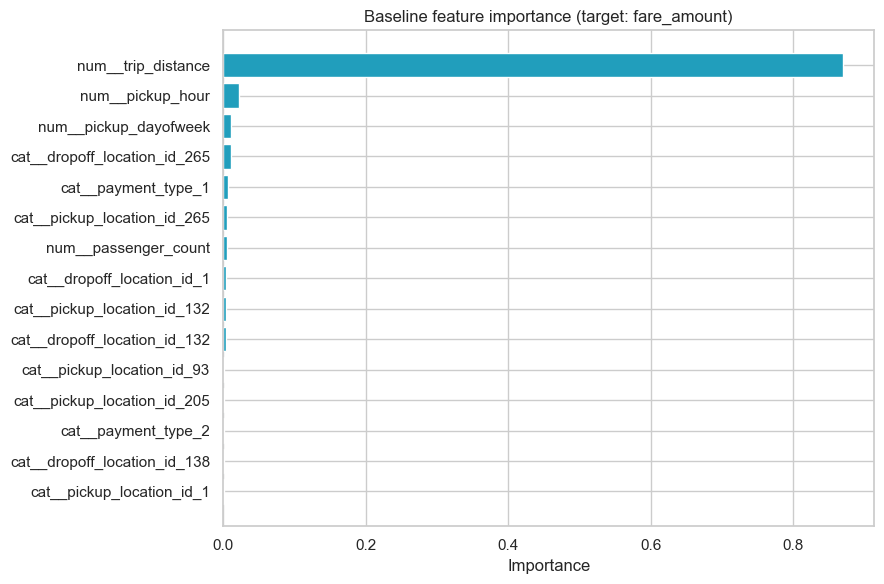

In [14]:
top_fi = fi.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_fi["feature"], top_fi["importance"], color="#219ebc")
ax.set_title("Baseline feature importance (target: fare_amount)")
ax.set_xlabel("Importance")
savefig("eda_baseline_feature_importance.png")
plt.show()


## 6) Summary notes (fill while reviewing outputs)

- Key data issues observed:
- Most common invalid record rules triggered:
- Strong demand patterns by hour/day/season:
- Borough/zone concentration findings:
- Recommended cleaning rules to apply in pipeline:
- Top baseline predictive signals:
